In [1]:
# import features
import pandas as pd
# acitvity entropy
df_entropy = pd.read_csv('../output/data_cleaned/activity_entropy_rates.csv')
print(df_entropy.shape)

# early warning scores (physiological)
df_EWS = pd.read_csv('../output/data_cleaned/Mian_warning_score.csv')
df_EWS.columns = ['patient_id', 'date', 'early_warning_score']


# sleep quality
df_sleep_quality = pd.read_csv('../output/sleep_score/sleep_quality_score_by_duration.csv')
df_sleep_quality = df_sleep_quality.drop(columns= ['sum', 'mean','scaled_sleep_quality_sum']).copy()
df_sleep_quality.columns = ['patient_id', 'date', 'sleep_quality_score']

# agitation
df_agitation = pd.read_csv('../output/data_cleaned/agitation_daily_counts.csv')

# uti
df_uti = pd.read_csv('../output/data_cleaned/uti_daily.csv')

merged_df = df_entropy
# merge dataframes
for df in [df_EWS, df_sleep_quality, df_agitation, df_uti]:
    print(df.shape)
    merged_df = pd.merge(merged_df, df, on=['patient_id', 'date'], how='outer')
    
# only consider the patients without NA in the following analysis (as the analysis itself will be individualized anyway)
analysis_df = merged_df.dropna(subset=['sleep_quality_score']).dropna(subset=['early_warning_score']).dropna(subset=['entropy_rate']).copy()
analysis_df =  analysis_df.fillna(0)

print(analysis_df.shape)
analysis_df 

(2722, 3)
(2160, 3)
(800, 3)
(115, 3)
(265, 3)
(660, 7)


,patient_id,date,entropy_rate,early_warning_score,sleep_quality_score,agitation_counts,uti_happen
219,0f352,2019-06-26,0.669008,0.0,2.233437,0.0,1.0
221,0f352,2019-06-28,0.613697,0.0,1.516700,0.0,0.0
222,0f352,2019-06-29,0.615494,0.0,-0.010261,0.0,1.0
223,0f352,2019-06-30,0.514768,0.0,2.607387,0.0,0.0
250,16f4b,2019-04-28,0.651879,0.0,-1.319084,0.0,0.0
...,...,...,...,...,...,...,...
2694,f220c,2019-06-06,0.620975,0.0,-2.627908,0.0,0.0
2696,f220c,2019-06-08,0.527123,0.0,2.607387,0.0,0.0
2706,f220c,2019-06-19,0.527442,0.0,2.607387,0.0,0.0
2709,f220c,2019-06-22,0.608841,0.0,2.607387,0.0,0.0


In [2]:
analysis_df['patient_id'].value_counts()

c55f8    79
ec812    70
c5785    66
55cd4    64
30a32    62
a2849    57
1fbe4    52
96adf    49
c8574    45
93c14    36
e2472    25
f220c    15
16f4b    13
d7a46    10
b0455     9
76230     4
0f352     4
Name: patient_id, dtype: int64

In [5]:
id_select = "ec812"
df_person = analysis_df[analysis_df['patient_id'] == id_select].copy()
df_person

,patient_id,date,entropy_rate,early_warning_score,sleep_quality_score,agitation_counts,uti_happen
2528,ec812,2019-04-09,0.684974,0.0,-0.010261,0.0,0.0
2529,ec812,2019-04-10,0.614688,0.0,0.316945,0.0,0.0
2530,ec812,2019-04-11,0.680348,0.0,-0.446535,0.0,0.0
2531,ec812,2019-04-12,0.668105,0.0,-0.337467,0.0,0.0
2532,ec812,2019-04-13,0.655223,0.0,0.363689,0.0,0.0
...,...,...,...,...,...,...,...
2594,ec812,2019-06-21,0.661363,0.0,-0.337467,0.0,0.0
2595,ec812,2019-06-22,0.623560,0.0,0.862288,0.0,0.0
2596,ec812,2019-06-23,0.708682,0.0,0.316945,0.0,0.0
2597,ec812,2019-06-24,0.656330,0.0,0.280589,0.0,0.0


In [6]:
from sklearn.preprocessing import StandardScaler
data = df_person.drop(columns = ['patient_id','date']).copy()
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 70 entries, 2528 to 2598
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   entropy_rate         70 non-null     float64
 1   early_warning_score  70 non-null     float64
 2   sleep_quality_score  70 non-null     float64
 3   agitation_counts     70 non-null     float64
 4   uti_happen           70 non-null     float64
dtypes: float64(5)
memory usage: 3.3 KB


In [7]:
def split_series(series, n_past, n_future):
  
  X, y = list(), list()
  for window_start in range(len(series)):
    past_end = window_start + n_past
    future_end = past_end + n_future
    if future_end > len(series):
      break
    past, future = series[window_start:past_end, :], series[past_end:future_end, :]
    X.append(past)
    y.append(future)
  return np.array(X), np.array(y)

In [8]:
analysis_df['patient_id'].unique()

array(['0f352', '16f4b', '1fbe4', '30a32', '55cd4', '76230', '93c14',
       '96adf', 'a2849', 'b0455', 'c55f8', 'c5785', 'c8574', 'd7a46',
       'e2472', 'ec812', 'f220c'], dtype=object)

# ALL IN ONE

Model: "functional_53"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_26      │ (None, 10, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_52 (LSTM)      │ [(None, 100),     │     42,400 │ input_layer_26[0… │
│                     │ (None, 100),      │            │                   │
│                     │ (None, 100)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_26    │ (None, 1, 100)    │          0 │ lstm_52[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_53 (LSTM)      │ (None, 1, 100)    │     80,400 │ repeat_vector_26… │
│                     │                   │            │ lstm_52[0][1],    │
│                     │                   │            │ lstm_52[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_26 │ (None, 1, 5)      │        505 │ lstm_53[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 123,305 (481.66 KB)

 Trainable params: 123,305 (481.66 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 623ms/step


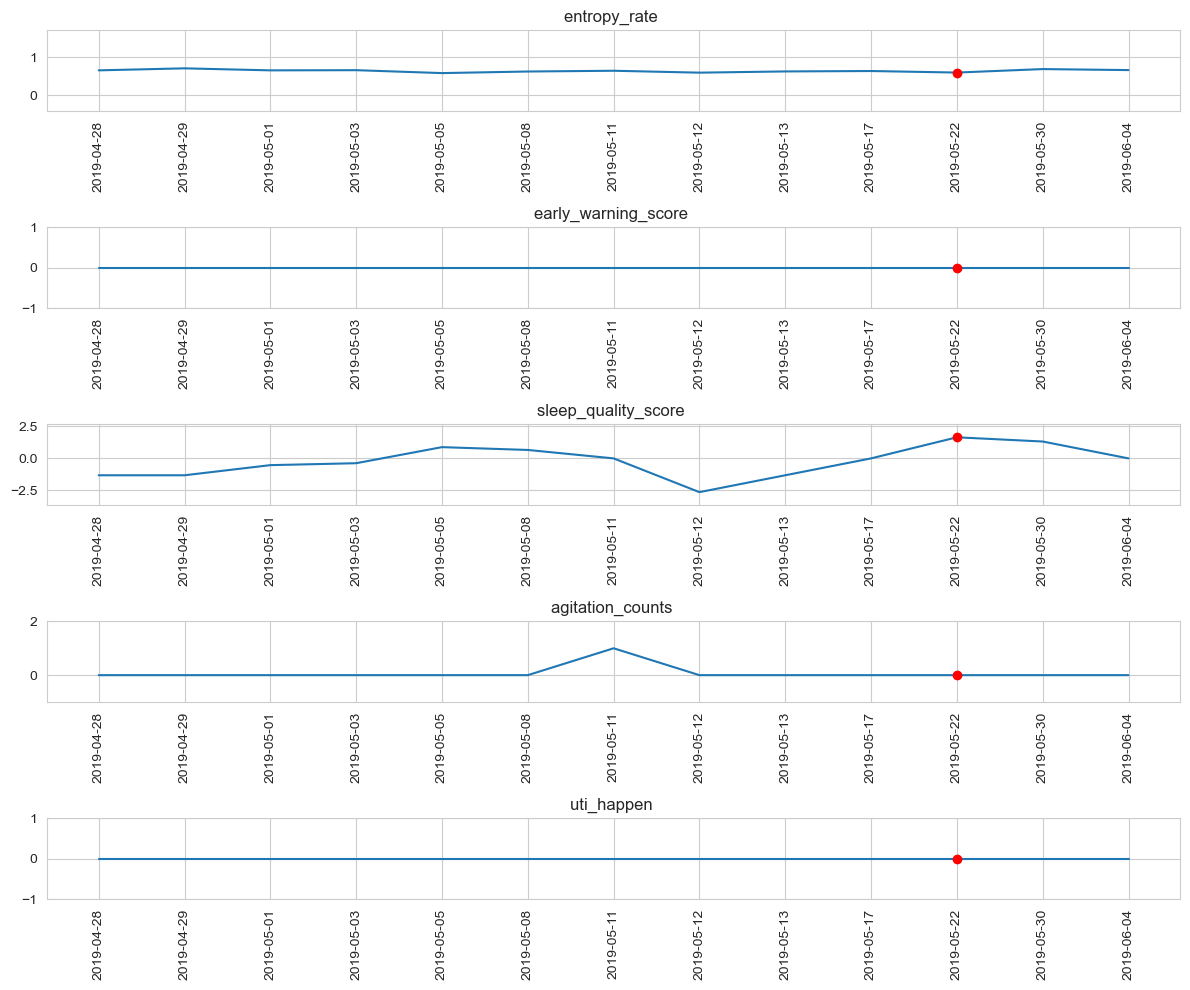

Model: "functional_55"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_27      │ (None, 10, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_54 (LSTM)      │ [(None, 100),     │     42,400 │ input_layer_27[0… │
│                     │ (None, 100),      │            │                   │
│                     │ (None, 100)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_27    │ (None, 1, 100)    │          0 │ lstm_54[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_55 (LSTM)      │ (None, 1, 100)    │     80,400 │ repeat_vector_27… │
│                     │                   │            │ lstm_54[0][1],    │
│                     │                   │            │ lstm_54[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_27 │ (None, 1, 5)      │        505 │ lstm_55[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 123,305 (481.66 KB)

 Trainable params: 123,305 (481.66 KB)

 Non-trainable params: 0 (0.00 B)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 316ms/step


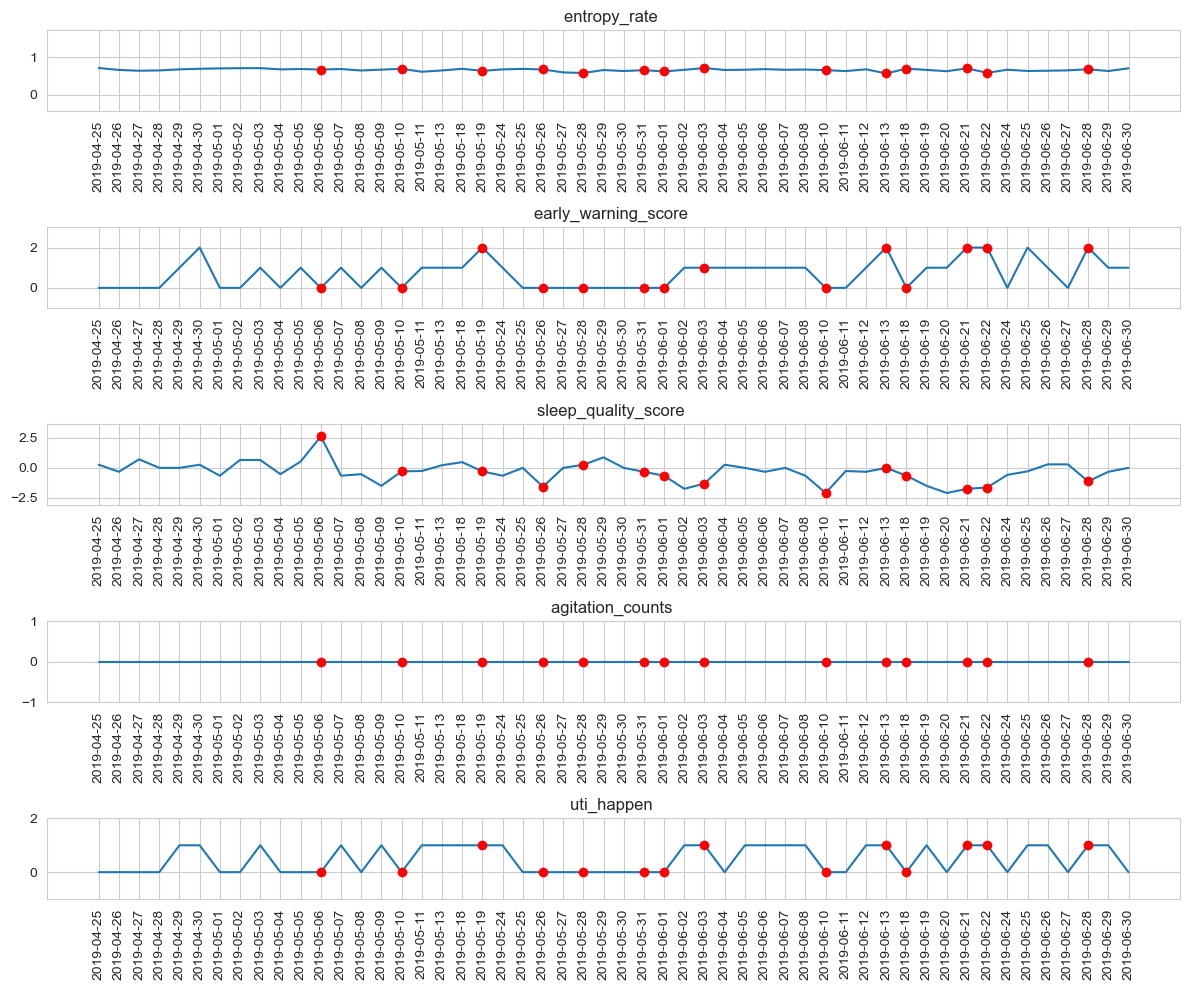

Model: "functional_57"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_28      │ (None, 10, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_56 (LSTM)      │ [(None, 100),     │     42,400 │ input_layer_28[0… │
│                     │ (None, 100),      │            │                   │
│                     │ (None, 100)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_28    │ (None, 1, 100)    │          0 │ lstm_56[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_57 (LSTM)      │ (None, 1, 100)    │     80,400 │ repeat_vector_28… │
│                     │                   │            │ lstm_56[0][1],    │
│                     │                   │            │ lstm_56[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_28 │ (None, 1, 5)      │        505 │ lstm_57[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 123,305 (481.66 KB)

 Trainable params: 123,305 (481.66 KB)

 Non-trainable params: 0 (0.00 B)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 665ms/step


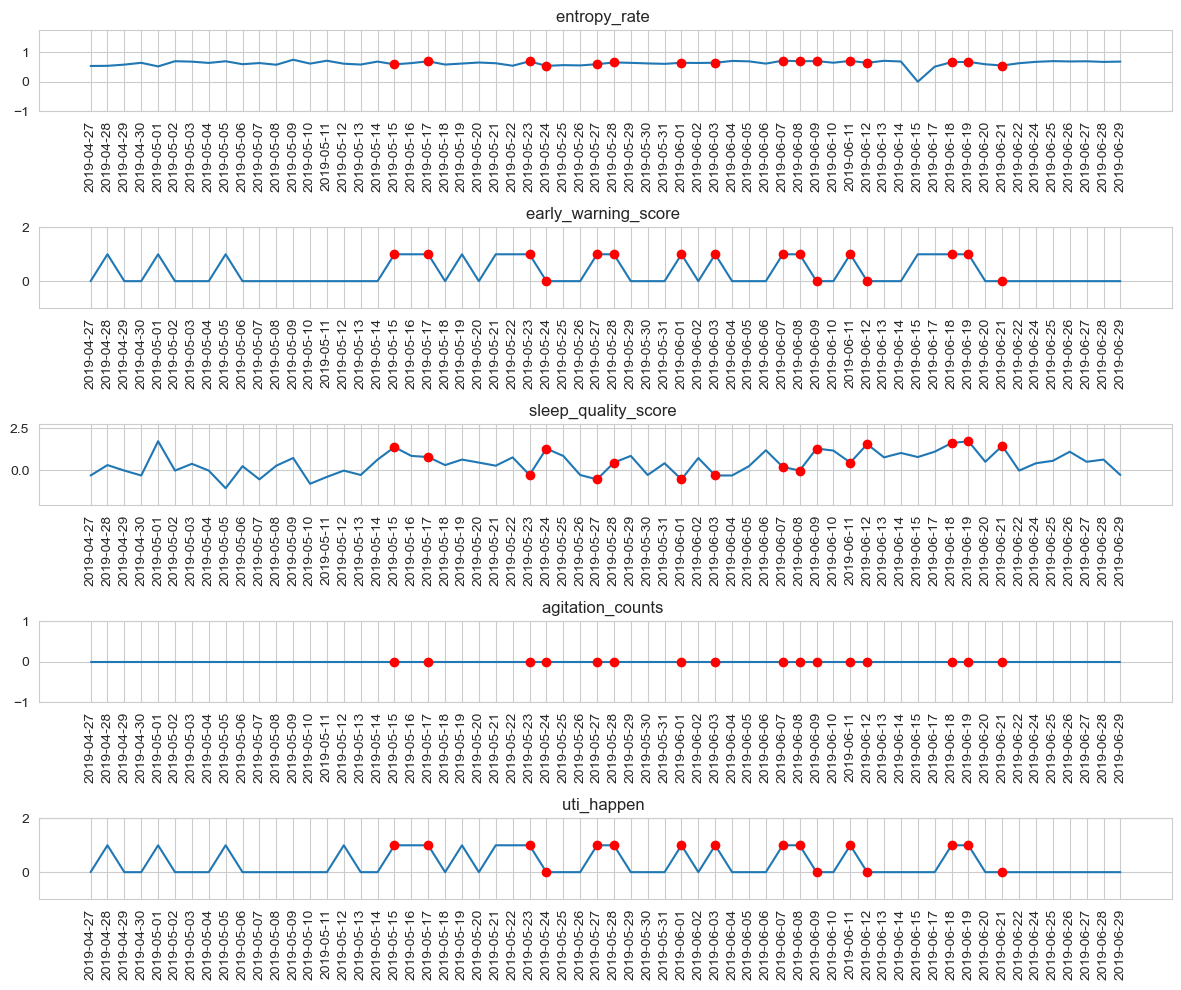

Model: "functional_59"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_29      │ (None, 10, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_58 (LSTM)      │ [(None, 100),     │     42,400 │ input_layer_29[0… │
│                     │ (None, 100),      │            │                   │
│                     │ (None, 100)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_29    │ (None, 1, 100)    │          0 │ lstm_58[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_59 (LSTM)      │ (None, 1, 100)    │     80,400 │ repeat_vector_29… │
│                     │                   │            │ lstm_58[0][1],    │
│                     │                   │            │ lstm_58[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_29 │ (None, 1, 5)      │        505 │ lstm_59[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 123,305 (481.66 KB)

 Trainable params: 123,305 (481.66 KB)

 Non-trainable params: 0 (0.00 B)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 416ms/step


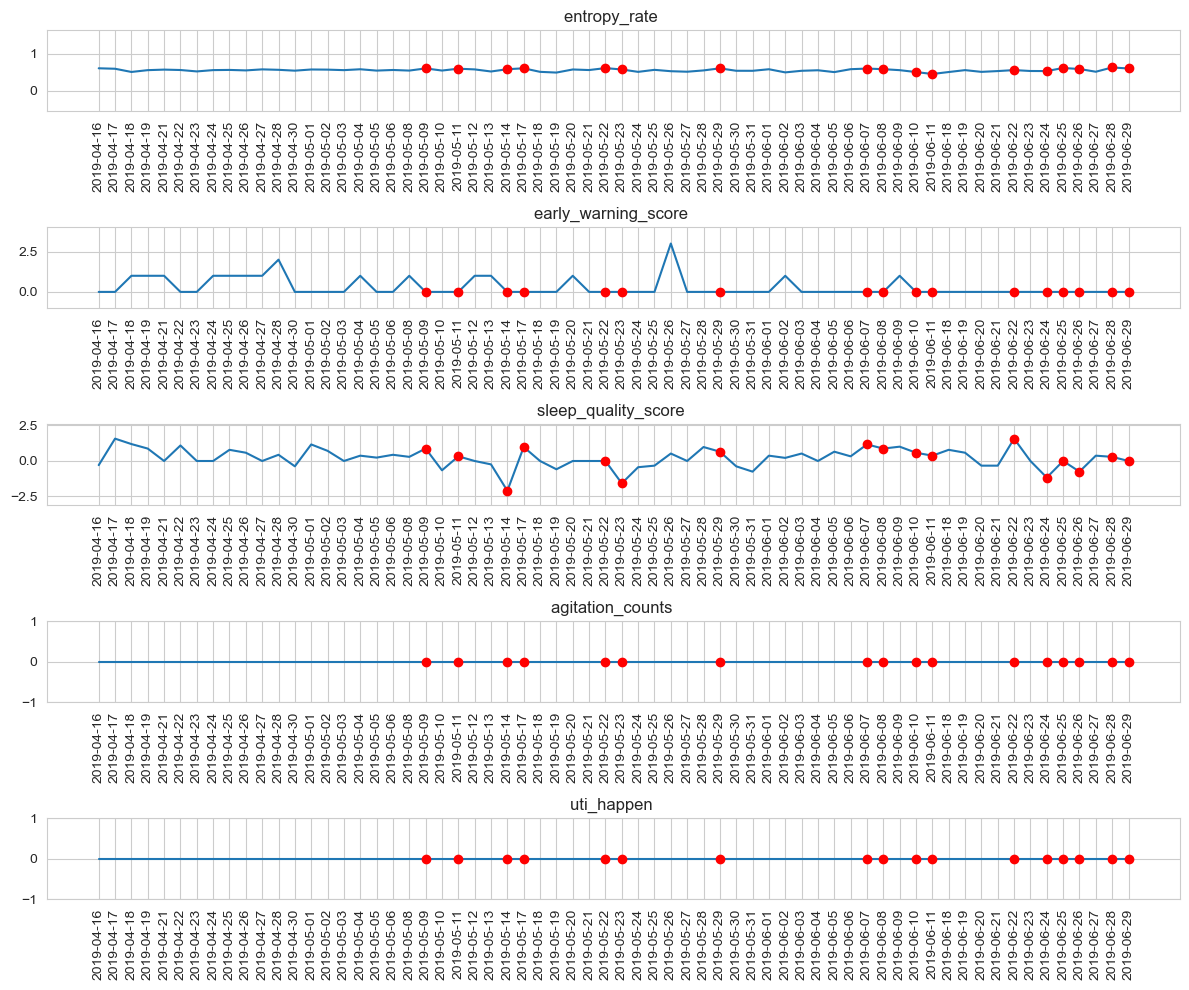

Model: "functional_61"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_30      │ (None, 10, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_60 (LSTM)      │ [(None, 100),     │     42,400 │ input_layer_30[0… │
│                     │ (None, 100),      │            │                   │
│                     │ (None, 100)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_30    │ (None, 1, 100)    │          0 │ lstm_60[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_61 (LSTM)      │ (None, 1, 100)    │     80,400 │ repeat_vector_30… │
│                     │                   │            │ lstm_60[0][1],    │
│                     │                   │            │ lstm_60[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_30 │ (None, 1, 5)      │        505 │ lstm_61[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 123,305 (481.66 KB)

 Trainable params: 123,305 (481.66 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step


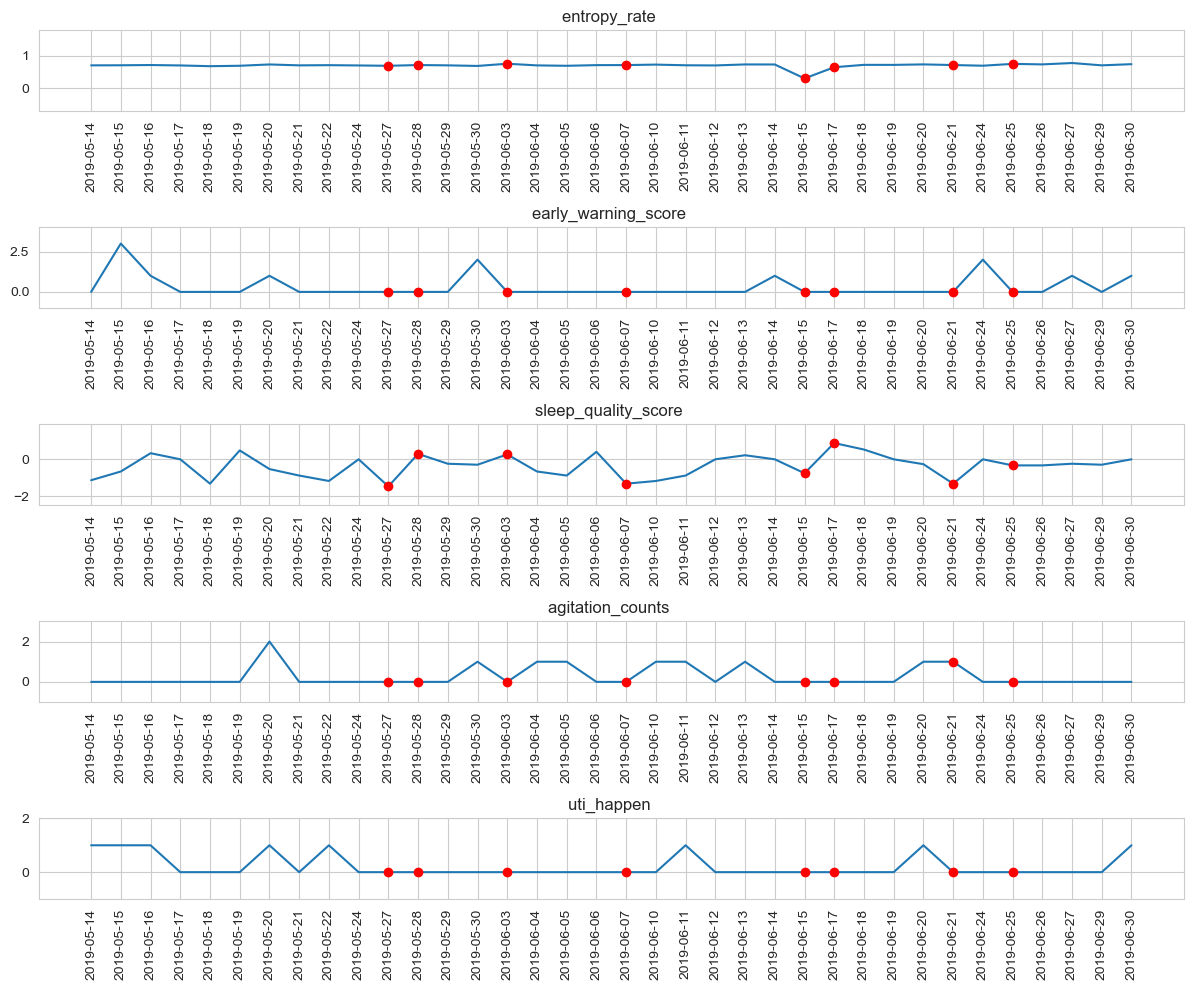

Model: "functional_63"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_31      │ (None, 10, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_62 (LSTM)      │ [(None, 100),     │     42,400 │ input_layer_31[0… │
│                     │ (None, 100),      │            │                   │
│                     │ (None, 100)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_31    │ (None, 1, 100)    │          0 │ lstm_62[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_63 (LSTM)      │ (None, 1, 100)    │     80,400 │ repeat_vector_31… │
│                     │                   │            │ lstm_62[0][1],    │
│                     │                   │            │ lstm_62[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_31 │ (None, 1, 5)      │        505 │ lstm_63[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 123,305 (481.66 KB)

 Trainable params: 123,305 (481.66 KB)

 Non-trainable params: 0 (0.00 B)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 328ms/step


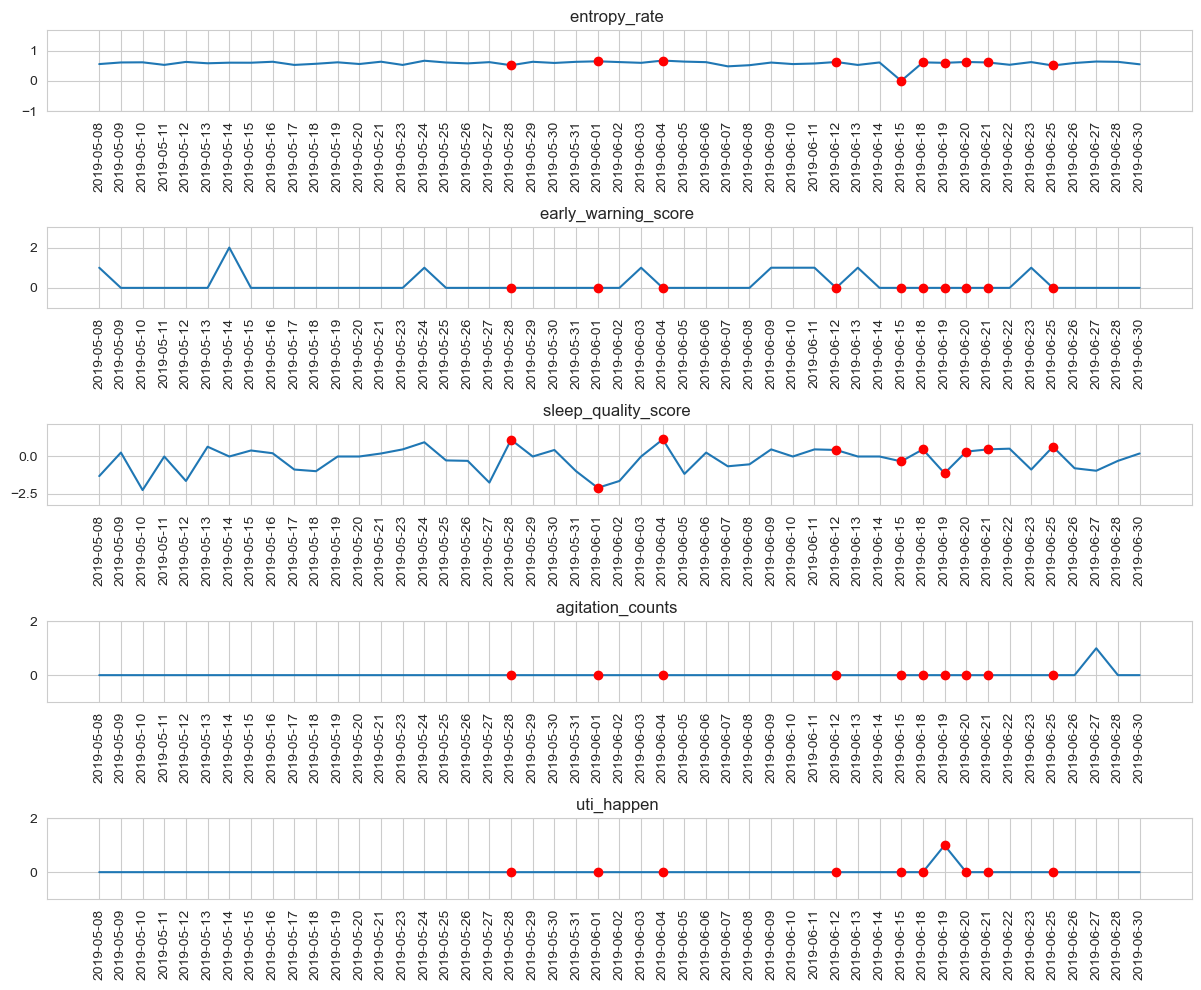

Model: "functional_65"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_32      │ (None, 10, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_64 (LSTM)      │ [(None, 100),     │     42,400 │ input_layer_32[0… │
│                     │ (None, 100),      │            │                   │
│                     │ (None, 100)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_32    │ (None, 1, 100)    │          0 │ lstm_64[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_65 (LSTM)      │ (None, 1, 100)    │     80,400 │ repeat_vector_32… │
│                     │                   │            │ lstm_64[0][1],    │
│                     │                   │            │ lstm_64[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_32 │ (None, 1, 5)      │        505 │ lstm_65[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 123,305 (481.66 KB)

 Trainable params: 123,305 (481.66 KB)

 Non-trainable params: 0 (0.00 B)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 621ms/step


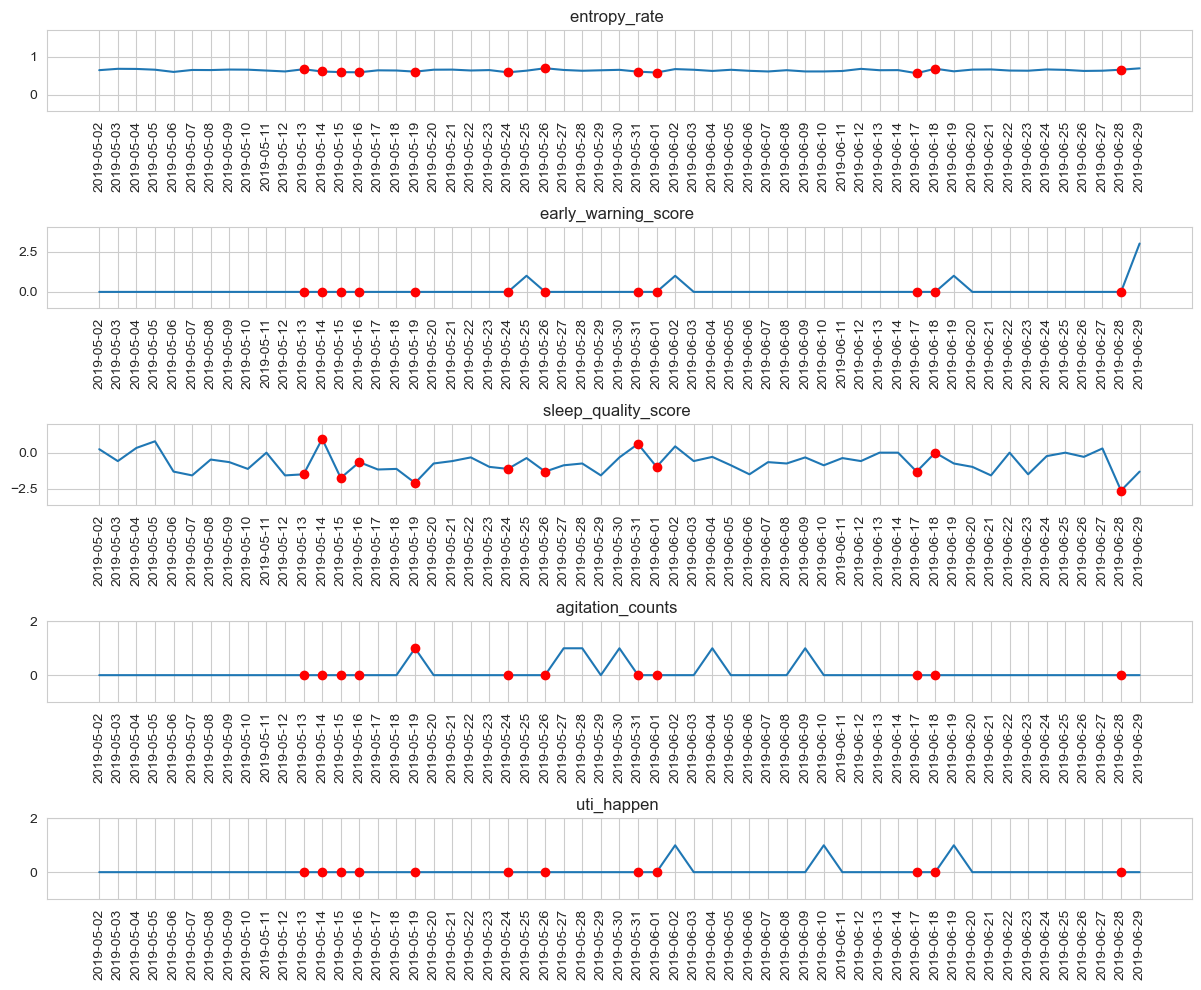

Model: "functional_67"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_33      │ (None, 10, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_66 (LSTM)      │ [(None, 100),     │     42,400 │ input_layer_33[0… │
│                     │ (None, 100),      │            │                   │
│                     │ (None, 100)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_33    │ (None, 1, 100)    │          0 │ lstm_66[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_67 (LSTM)      │ (None, 1, 100)    │     80,400 │ repeat_vector_33… │
│                     │                   │            │ lstm_66[0][1],    │
│                     │                   │            │ lstm_66[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_33 │ (None, 1, 5)      │        505 │ lstm_67[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 123,305 (481.66 KB)

 Trainable params: 123,305 (481.66 KB)

 Non-trainable params: 0 (0.00 B)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step


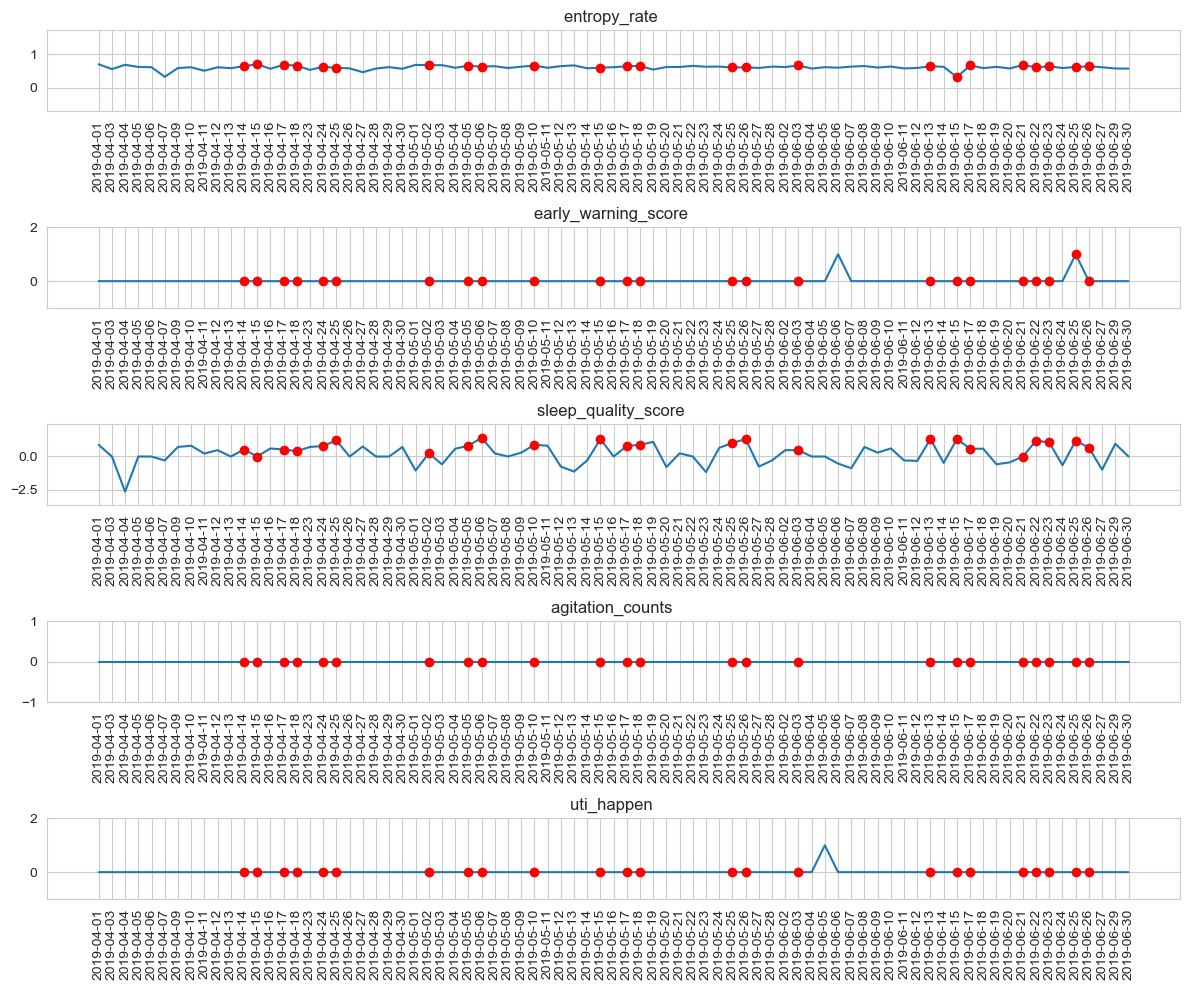

Model: "functional_69"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_34      │ (None, 10, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_68 (LSTM)      │ [(None, 100),     │     42,400 │ input_layer_34[0… │
│                     │ (None, 100),      │            │                   │
│                     │ (None, 100)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_34    │ (None, 1, 100)    │          0 │ lstm_68[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_69 (LSTM)      │ (None, 1, 100)    │     80,400 │ repeat_vector_34… │
│                     │                   │            │ lstm_68[0][1],    │
│                     │                   │            │ lstm_68[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_34 │ (None, 1, 5)      │        505 │ lstm_69[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 123,305 (481.66 KB)

 Trainable params: 123,305 (481.66 KB)

 Non-trainable params: 0 (0.00 B)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 926ms/step


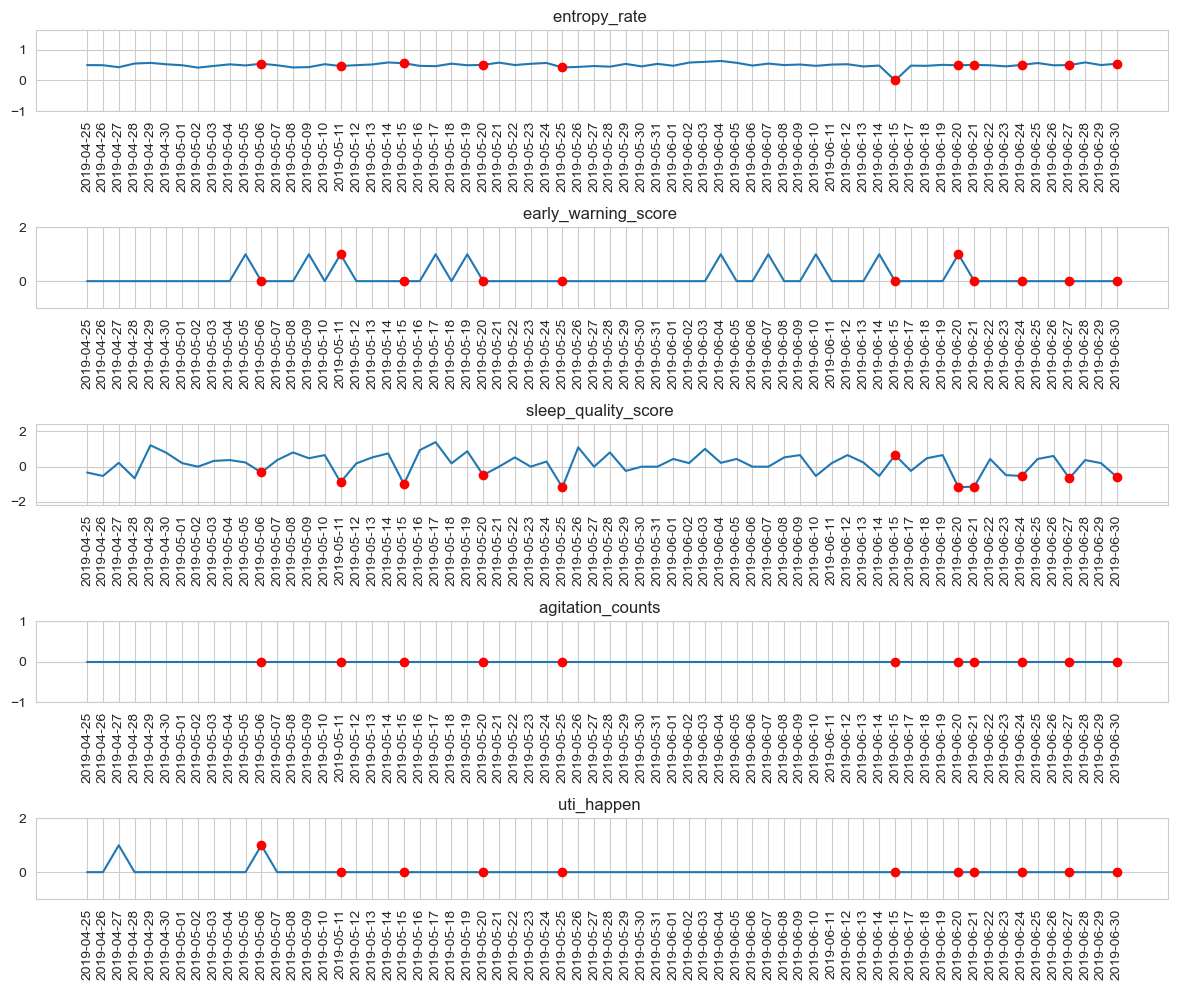

Model: "functional_71"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_35      │ (None, 10, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_70 (LSTM)      │ [(None, 100),     │     42,400 │ input_layer_35[0… │
│                     │ (None, 100),      │            │                   │
│                     │ (None, 100)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_35    │ (None, 1, 100)    │          0 │ lstm_70[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_71 (LSTM)      │ (None, 1, 100)    │     80,400 │ repeat_vector_35… │
│                     │                   │            │ lstm_70[0][1],    │
│                     │                   │            │ lstm_70[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_35 │ (None, 1, 5)      │        505 │ lstm_71[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 123,305 (481.66 KB)

 Trainable params: 123,305 (481.66 KB)

 Non-trainable params: 0 (0.00 B)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 414ms/step


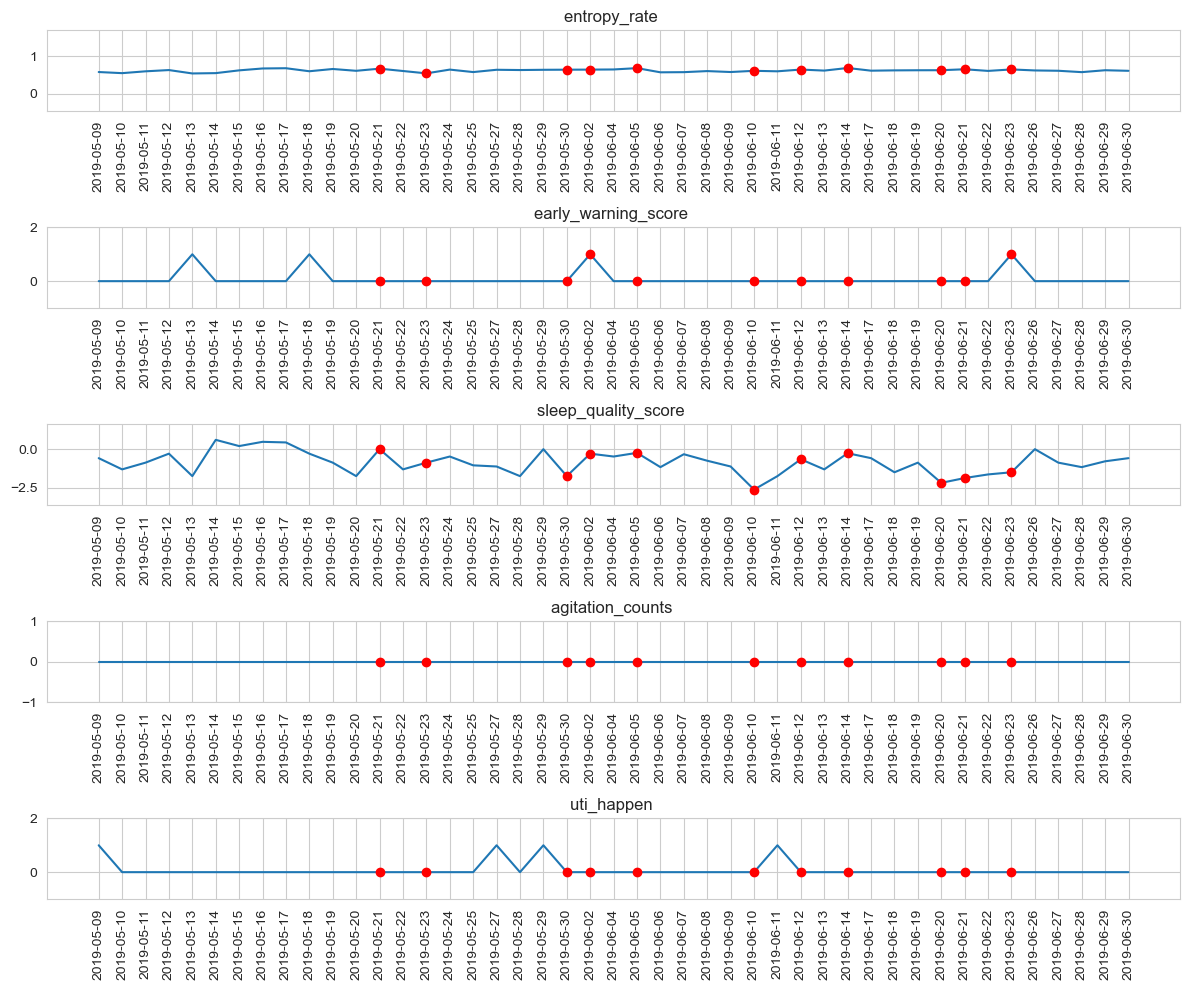

Model: "functional_73"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_36      │ (None, 10, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_72 (LSTM)      │ [(None, 100),     │     42,400 │ input_layer_36[0… │
│                     │ (None, 100),      │            │                   │
│                     │ (None, 100)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_36    │ (None, 1, 100)    │          0 │ lstm_72[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_73 (LSTM)      │ (None, 1, 100)    │     80,400 │ repeat_vector_36… │
│                     │                   │            │ lstm_72[0][1],    │
│                     │                   │            │ lstm_72[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_36 │ (None, 1, 5)      │        505 │ lstm_73[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 123,305 (481.66 KB)

 Trainable params: 123,305 (481.66 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step


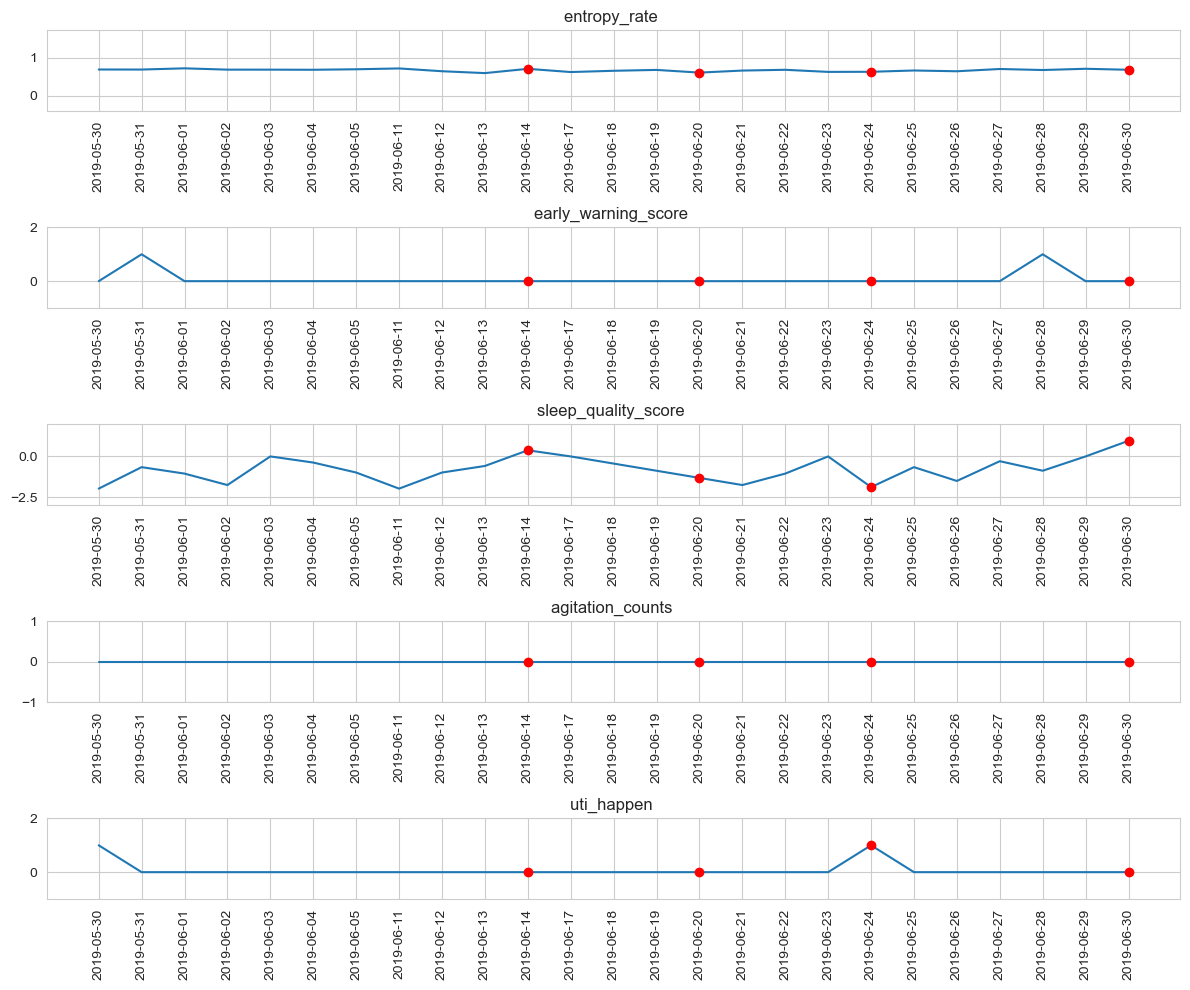

Model: "functional_75"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_37      │ (None, 10, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_74 (LSTM)      │ [(None, 100),     │     42,400 │ input_layer_37[0… │
│                     │ (None, 100),      │            │                   │
│                     │ (None, 100)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_37    │ (None, 1, 100)    │          0 │ lstm_74[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_75 (LSTM)      │ (None, 1, 100)    │     80,400 │ repeat_vector_37… │
│                     │                   │            │ lstm_74[0][1],    │
│                     │                   │            │ lstm_74[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_37 │ (None, 1, 5)      │        505 │ lstm_75[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 123,305 (481.66 KB)

 Trainable params: 123,305 (481.66 KB)

 Non-trainable params: 0 (0.00 B)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 298ms/step


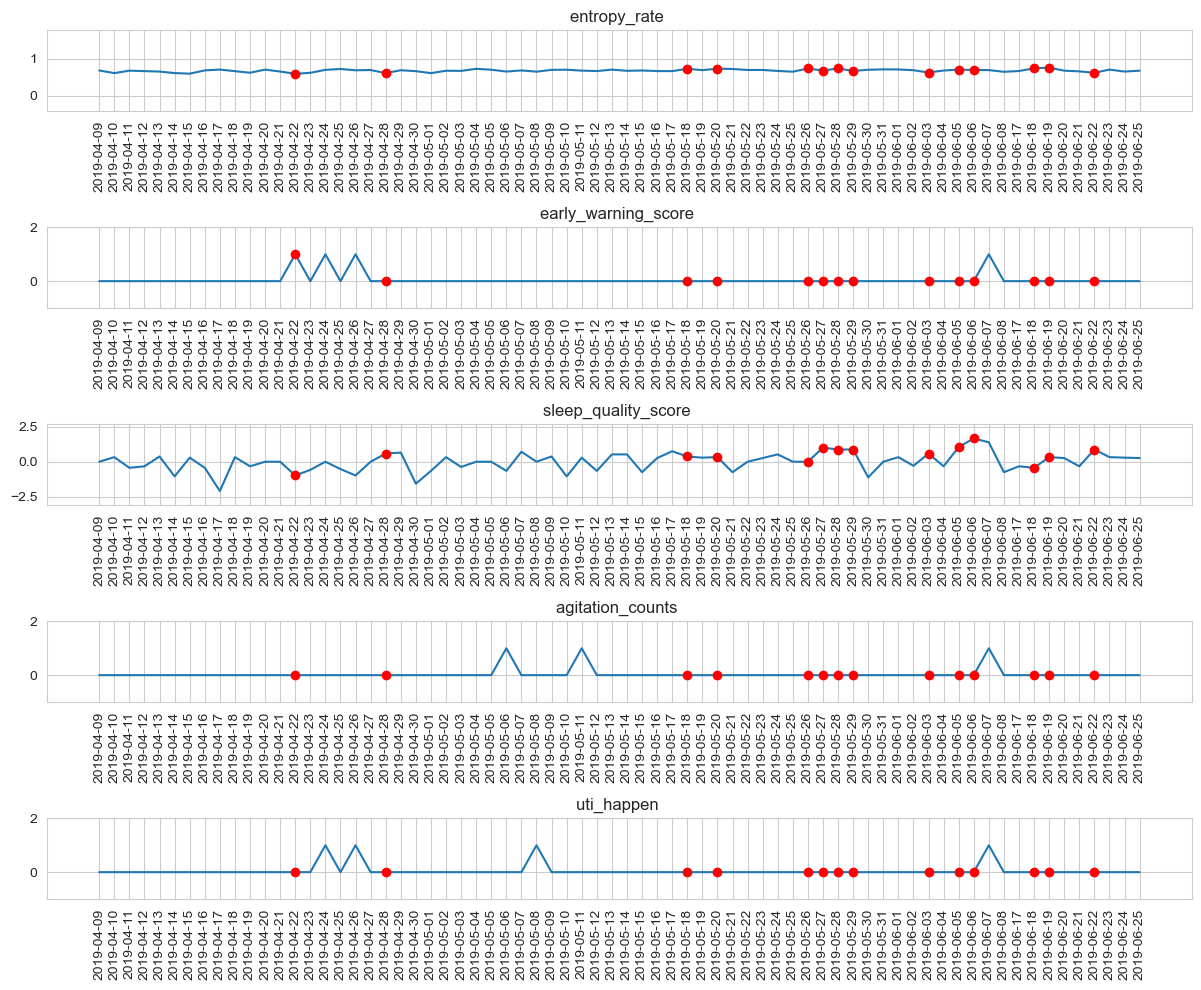

Model: "functional_77"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_38      │ (None, 10, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_76 (LSTM)      │ [(None, 100),     │     42,400 │ input_layer_38[0… │
│                     │ (None, 100),      │            │                   │
│                     │ (None, 100)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_38    │ (None, 1, 100)    │          0 │ lstm_76[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_77 (LSTM)      │ (None, 1, 100)    │     80,400 │ repeat_vector_38… │
│                     │                   │            │ lstm_76[0][1],    │
│                     │                   │            │ lstm_76[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_38 │ (None, 1, 5)      │        505 │ lstm_77[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 123,305 (481.66 KB)

 Trainable params: 123,305 (481.66 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step


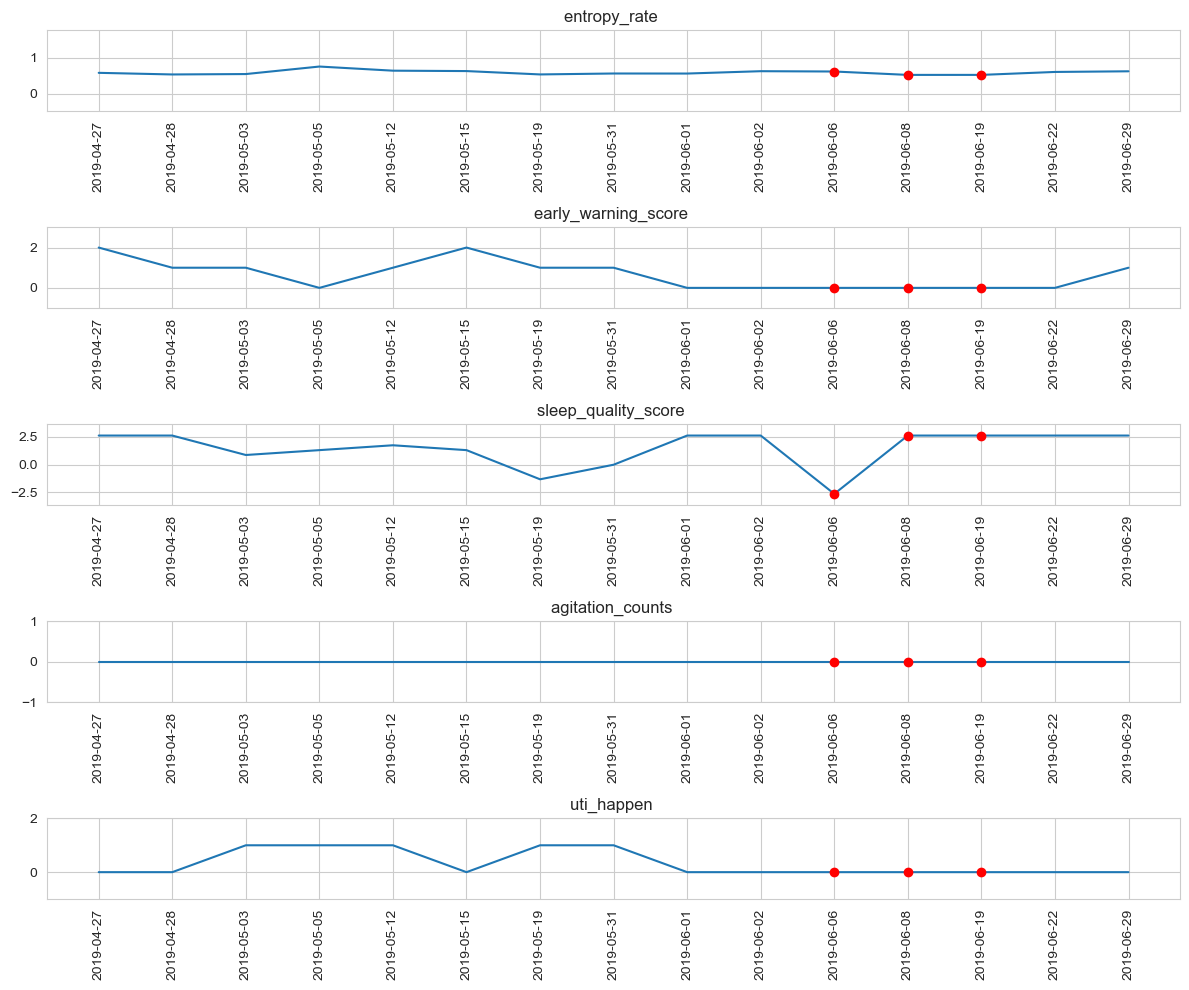

In [12]:
dfs_anomaly_all = []
days_baseline = 10

for id_select in  analysis_df['patient_id'].unique():
    df_person = analysis_df[analysis_df['patient_id'] == id_select].copy()
    if df_person.shape[0] > days_baseline:
        data = df_person.drop(columns = ['patient_id','date']).copy()
        train_df = data.copy()


        from sklearn.preprocessing import MinMaxScaler
        import numpy as np
        
        train = train_df.copy()
        scalers={}
        for i in train_df.columns:
            scaler = MinMaxScaler(feature_range=(-1,1))
            s_s = scaler.fit_transform(train[i].values.reshape(-1,1))
            s_s=np.reshape(s_s,len(s_s))
            scalers['scaler_'+ i] = scaler
            train[i]=s_s
            
            
        n_past = days_baseline
        n_future = 1
        n_features = 5
        
        X_train, y_train = split_series(train.values,n_past, n_future)
        X_train = X_train.reshape((X_train.shape[0], X_train.shape[1],n_features))
        y_train = y_train.reshape((y_train.shape[0], y_train.shape[1], n_features))
        
        
        # E1D1: Sequence to Sequence Model with one encoder layer and one decoder layer
        import tensorflow as tf
        encoder_inputs = tf.keras.layers.Input(shape=(n_past, n_features))
        encoder_l1 = tf.keras.layers.LSTM(100, return_state=True)
        encoder_outputs1 = encoder_l1(encoder_inputs)
        
        encoder_states1 = encoder_outputs1[1:]
        
        decoder_inputs = tf.keras.layers.RepeatVector(n_future)(encoder_outputs1[0])
        
        decoder_l1 = tf.keras.layers.LSTM(100, return_sequences=True)(decoder_inputs,initial_state = encoder_states1)
        decoder_outputs1 = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(n_features))(decoder_l1)
        
        model_e1d1 = tf.keras.models.Model(encoder_inputs, decoder_outputs1)
        
        model_e1d1.summary()
        
        reduce_lr = tf.keras.callbacks.LearningRateScheduler(lambda x: 1e-3 * 0.90 ** x)
        model_e1d1.compile(optimizer=tf.keras.optimizers.Adam(), loss=tf.keras.losses.Huber())
        
        
        
        pred_e1d1 = model_e1d1.predict(X_train)
        
        arr_2d = pred_e1d1.reshape(pred_e1d1.shape[0], n_features)
        df_pred = pd.DataFrame(arr_2d, columns = ['entropy_rate', 'early_warning_score', 'sleep_quality_score', 'agitation_counts', 'uti_happen'])
        
        arr_2d = y_train.reshape(pred_e1d1.shape[0], n_features)
        df_actual = pd.DataFrame(arr_2d, columns = ['entropy_rate', 'early_warning_score', 'sleep_quality_score', 'agitation_counts', 'uti_happen'])
        
        errors = np.mean(np.square(df_pred.values - df_actual.values), axis=1)

        mean_error = np.mean(errors)
        std_error = np.std(errors)
        SD_MUPLIPLIER = 0.5
        threshold = mean_error + SD_MUPLIPLIER * std_error 
        anomalies = errors > threshold
        
        
        data_plot = df_person.copy()
        data_plot['anomaly'] = np.append([np.nan] * (len(data_plot) - len(anomalies)), anomalies)   
        
        anomaly_df = data_plot.query('anomaly == 1')
        dfs_anomaly_all.append(anomaly_df)
        
        import matplotlib.pyplot as plt

        # Set the figure size
        plt.figure(figsize=(12, 10))
        
        # Plot each variable
        for i, column in enumerate(data_plot[['entropy_rate', 'early_warning_score', 'sleep_quality_score', 'agitation_counts', 'uti_happen']]):
            plt.subplot(5, 1, i+1)  # 4x1 grid for 4 variables, including empty ones for better arrangement
            plt.plot(data_plot['date'], data_plot[column], label=column)
            
            # # Highlight specific index in red
            if anomaly_df.shape[0]>0:
                plt.scatter(anomaly_df['date'], anomaly_df[column], color='red', label='anomaly', zorder=5)
               
            # Title and labels
            plt.title(f'{column} ')
            plt.xlabel('')
            plt.ylabel('')
            plt.xticks(rotation=90)
            
            # Optional: Adjusting the y-axis range to fit all data in the plots
            plt.ylim(data_plot[column].min() - 1, data_plot[column].max() + 1)
        
        # Adjust layout and show plot
        plt.tight_layout()
        
        plt.savefig('../output/Anomaly_delirium/LSTM/anomaly_LSTM_' + id_select + '.png', dpi=300)
        plt.show()
dfs_anomaly_all = pd.concat(dfs_anomaly_all, ignore_index=True)   
dfs_anomaly_all.to_csv("../output/Anomaly_delirium/LSTM/LSTM_anomaly_data.csv", index=False)

In [10]:
dfs_anomaly_all

,patient_id,date,entropy_rate,early_warning_score,sleep_quality_score,agitation_counts,uti_happen,anomaly
0,1fbe4,2019-05-06,0.668119,0.0,2.607387,0.0,0.0,1.0
1,1fbe4,2019-06-21,0.700437,2.0,-1.755359,0.0,1.0,1.0
2,1fbe4,2019-06-22,0.580818,2.0,-1.646290,0.0,1.0,1.0
3,30a32,2019-05-15,0.590749,1.0,1.385818,0.0,1.0,1.0
4,30a32,2019-06-15,0.000000,1.0,0.795169,0.0,0.0,1.0
5,30a32,2019-06-18,0.666992,1.0,1.625769,0.0,1.0,1.0
6,30a32,2019-06-19,0.676556,1.0,1.734838,0.0,1.0,1.0
7,55cd4,2019-05-14,0.586062,0.0,-2.104379,0.0,0.0,1.0
8,55cd4,2019-06-07,0.603416,0.0,1.153138,0.0,0.0,1.0
9,55cd4,2019-06-28,0.633688,0.0,0.280589,0.0,0.0,1.0


# reference : https://www.kaggle.com/code/sasakitetsuya/multivariate-time-series-forecasting-with-lstms/notebook


In [10]:
train_df = data.copy()


from sklearn.preprocessing import MinMaxScaler
import numpy as np

train = train_df.copy()
scalers={}
for i in train_df.columns:
    scaler = MinMaxScaler(feature_range=(-1,1))
    s_s = scaler.fit_transform(train[i].values.reshape(-1,1))
    s_s=np.reshape(s_s,len(s_s))
    scalers['scaler_'+ i] = scaler
    train[i]=s_s
    
    
n_past = 5
n_future = 1
n_features = 5

X_train, y_train = split_series(train.values,n_past, n_future)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1],n_features))
y_train = y_train.reshape((y_train.shape[0], y_train.shape[1], n_features))


# E1D1: Sequence to Sequence Model with one encoder layer and one decoder layer
import tensorflow as tf
encoder_inputs = tf.keras.layers.Input(shape=(n_past, n_features))
encoder_l1 = tf.keras.layers.LSTM(100, return_state=True)
encoder_outputs1 = encoder_l1(encoder_inputs)

encoder_states1 = encoder_outputs1[1:]

decoder_inputs = tf.keras.layers.RepeatVector(n_future)(encoder_outputs1[0])

decoder_l1 = tf.keras.layers.LSTM(100, return_sequences=True)(decoder_inputs,initial_state = encoder_states1)
decoder_outputs1 = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(n_features))(decoder_l1)

model_e1d1 = tf.keras.models.Model(encoder_inputs, decoder_outputs1)

model_e1d1.summary()

reduce_lr = tf.keras.callbacks.LearningRateScheduler(lambda x: 1e-3 * 0.90 ** x)
model_e1d1.compile(optimizer=tf.keras.optimizers.Adam(), loss=tf.keras.losses.Huber())


Model: "functional_33"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 5, 5)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_32 (LSTM)      │ [(None, 100),     │     42,400 │ input_layer_16[0… │
│                     │ (None, 100),      │            │                   │
│                     │ (None, 100)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_16    │ (None, 1, 100)    │          0 │ lstm_32[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_33 (LSTM)      │ (None, 1, 100)    │     80,400 │ repeat_vector_16… │
│                     │                   │            │ lstm_32[0][1],    │
│                     │                   │            │ lstm_32[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_16 │ (None, 1, 5)      │        505 │ lstm_33[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 123,305 (481.66 KB)

 Trainable params: 123,305 (481.66 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
pred_e1d1 = model_e1d1.predict(X_train)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step


In [15]:
arr_2d = pred_e1d1.reshape(pred_e1d1.shape[0], n_features)
df_pred = pd.DataFrame(arr_2d, columns = ['entropy_rate', 'early_warning_score', 'sleep_quality_score', 'agitation_counts', 'uti_happen'])
df_pred

,entropy_rate,early_warning_score,sleep_quality_score,agitation_counts,uti_happen
0,-0.005629,0.003251,-0.081742,0.023451,-0.020106
1,-0.024819,0.006044,-0.104998,0.027245,-0.021625
2,-0.020947,0.010291,-0.076510,0.079772,-0.043364
3,-0.023693,0.016866,-0.067584,0.091549,-0.050785
4,-0.058758,0.023599,-0.079124,0.051844,-0.039301
5,-0.063244,0.009766,-0.083751,0.015905,-0.006472
6,-0.054630,-0.022552,-0.062272,0.036291,0.031351
7,-0.076268,-0.016609,-0.067096,0.020418,0.016278
8,-0.094709,-0.012634,-0.063492,0.010690,0.010983
9,-0.088453,-0.016115,-0.066334,-0.000130,0.017036


In [17]:
arr_2d = y_train.reshape(pred_e1d1.shape[0], n_features)
df_actual = pd.DataFrame(arr_2d, columns = ['entropy_rate', 'early_warning_score', 'sleep_quality_score', 'agitation_counts', 'uti_happen'])
df_actual

,entropy_rate,early_warning_score,sleep_quality_score,agitation_counts,uti_happen
0,-0.084798,1.0,-5.000000e-01,-1.0,-1.0
1,-0.887734,0.0,5.000000e-01,-1.0,1.0
2,-0.664819,0.0,-1.387779e-17,-1.0,1.0
3,-0.676097,-1.0,-1.000000e+00,-1.0,-1.0
4,-0.113657,-1.0,-1.000000e+00,-1.0,-1.0
5,-0.188706,-1.0,1.000000e+00,-1.0,-1.0
6,-1.000000,-1.0,-1.000000e+00,-1.0,-1.0
7,-0.997244,-1.0,-1.000000e+00,-1.0,-1.0
8,-0.293598,-1.0,-1.000000e+00,-1.0,-1.0
9,-0.137101,0.0,-1.000000e+00,-1.0,-1.0


In [18]:
errors = np.mean(np.square(df_pred.values - df_actual.values), axis=1)

mean_error = np.mean(errors)
std_error = np.std(errors)

threshold = mean_error + 1.5 * std_error 
anomalies = errors > threshold
anomalies

array([False, False, False, False, False, False, False, False, False,
       False])

In [19]:
errors[anomalies]

array([], dtype=float64)

In [20]:
data_plot = df_person.copy()
data_plot['anomaly'] = np.append([np.nan] * (len(data_plot) - len(anomalies)), anomalies)
data_plot

,patient_id,date,entropy_rate,early_warning_score,sleep_quality_score,agitation_counts,uti_happen,anomaly
2654,f220c,2019-04-27,0.584277,2.0,-2.607387,0.0,0.0,NaN
2655,f220c,2019-04-28,0.539405,1.0,-2.607387,0.0,0.0,NaN
2660,f220c,2019-05-03,0.550437,1.0,-0.862288,0.0,1.0,NaN
2662,f220c,2019-05-05,0.758488,0.0,-1.298563,0.0,1.0,NaN
2669,f220c,2019-05-12,0.643946,1.0,-1.734838,0.0,1.0,NaN
2672,f220c,2019-05-15,0.632996,2.0,-1.298563,0.0,0.0,0.0
2676,f220c,2019-05-19,0.540110,1.0,1.319084,0.0,1.0,0.0
2688,f220c,2019-05-31,0.565897,1.0,0.010261,0.0,1.0,0.0
2689,f220c,2019-06-01,0.564593,0.0,-2.607387,0.0,0.0,0.0
2690,f220c,2019-06-02,0.629657,0.0,-2.607387,0.0,0.0,0.0


In [21]:
anomaly_df = data_plot.query('anomaly == 1')
anomaly_df 

,patient_id,date,entropy_rate,early_warning_score,sleep_quality_score,agitation_counts,uti_happen,anomaly


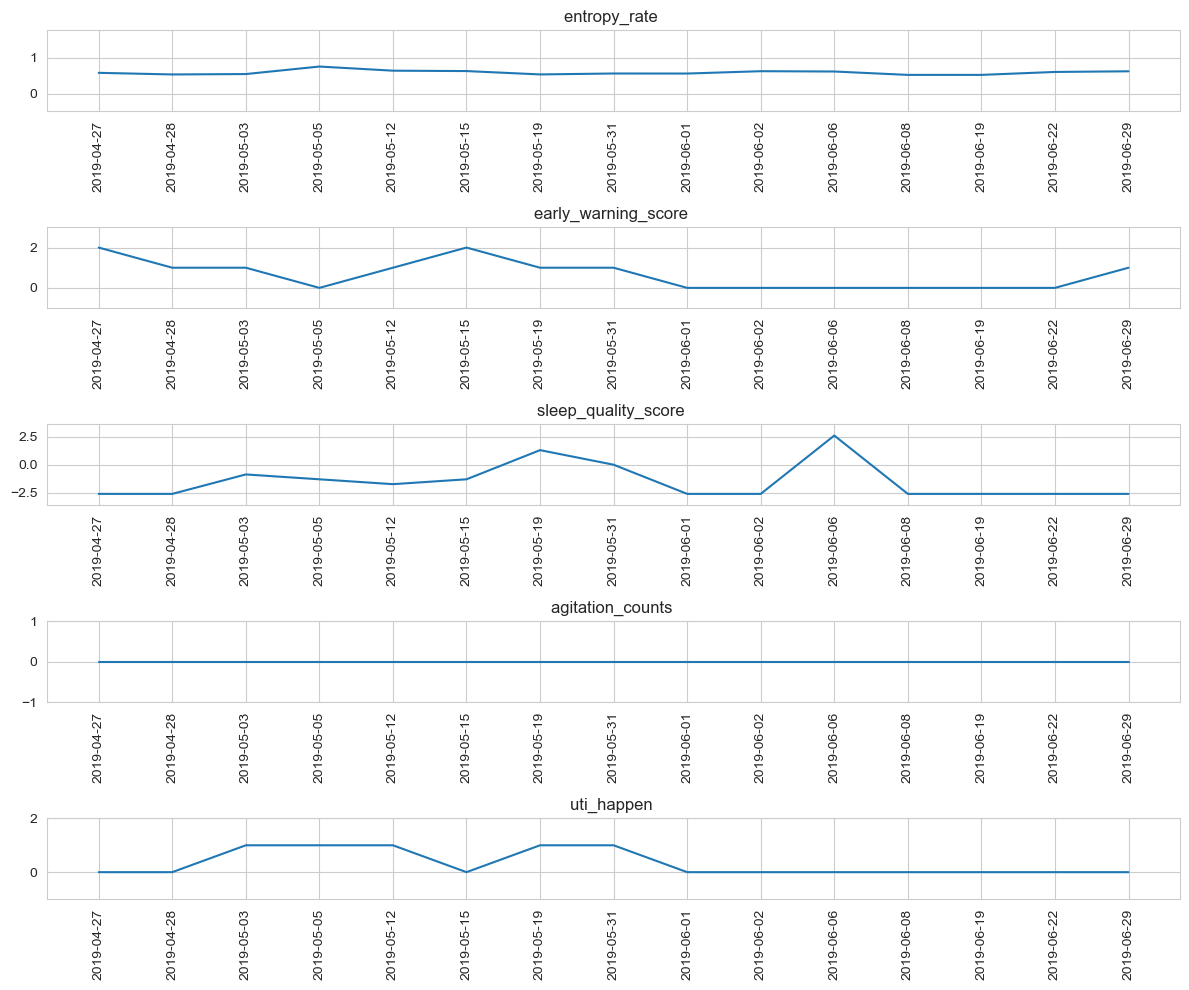

In [24]:
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(12, 10))

# Plot each variable
for i, column in enumerate(data_plot[['entropy_rate', 'early_warning_score', 'sleep_quality_score', 'agitation_counts', 'uti_happen']]):
    plt.subplot(5, 1, i+1)  
    plt.plot(data_plot['date'], data_plot[column], label=column)
    
    # # Highlight specific index in red
    plt.scatter(anomaly_df['date'], anomaly_df[column], color='red', label='anomaly', zorder=5)
       
    # Title and labels
    plt.title(f'{column} ')
    plt.xlabel('')
    plt.ylabel('')
    plt.xticks(rotation=90)
    
    # Optional: Adjusting the y-axis range to fit all data in the plots
    plt.ylim(data_plot[column].min() - 1, data_plot[column].max() + 1)

# Adjust layout and show plot
plt.tight_layout()

plt.savefig('../output/Anomaly_delirium/anomaly_ForestIsolation_' + id_select + '.png', dpi=300)
plt.show()